<a href="https://colab.research.google.com/github/luciavilchez23/SimulacionPAS/blob/main/MC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cadenas de Markov
El objetivo es aprender a simular trayectorias de una MC, usando algunas de las herramientas más habituales de machine learning. Como resultado final, generaremos algunas de las imágenes vistas en las clases teóricas, y haremos simulaciones relacionadas con los dos teoremas de convergencia que hemos visto: el teorema de convergencia de MCs y el teorema ergódico.

In [80]:
# Importación de librerías
import numpy as np
import matplotlib.pyplot as plt
import math

## Simular la trayectoria de un MC
Vamos a definir una función que nos permita generar trayectorias de una MC dada. Primero la definiremos de la manera más sencilla, usando dos bucles ```for```. Después veremos que se puede eliminar uno de los bucles para hacerlo más eficiente.

**Importante**: para una MC con $m$ estados, nosotros nos hemos referido a ellos como $\{1,2,\dots,m\}$. Y queremos que esta función que simula trayectorias nos devuelva efectivamente esos posibles estados. Hay al menos dos formas de hacer esto:

1. Hacer toda la implementación usando dicha nomenclatura: $\{1,2,\dots,m\}$.

2. Hacer la implementación usando la siguiente nomenclatura: $\{0,1,\dots,m-1\}$. Es decir, al estado $i$-ésimo pasamos a llamarlo "estado $i-1$" durante la implementación. Y, al final de la función, cuando vayamos a devolver los valores, sumamos $+1$ para que el usuario reciba la verdadera nomenclatura.

La opción 1. parece más sencilla desde el punto de vista lógico. Pero, a la hora de hacer la implementación, puesto que Numpy empieza la indexación en 0 (es decir, el primer elemento de un array de numpy está en la posición 0), el código queda mucho más sencillo y limpio si usamos la opción 2.

In [81]:
# Función para la simulación de las trayectorias usando un bucle for
def simular_trayectorias(P, pi_sup_1, n_samples, n_steps):

  # Paso 0: variable que guarde el número de estados
  m = np.size(pi_sup_1)

  # Paso 1: crear un array de shape (n_samples,n_steps)
  trayectorias = np.zeros((n_samples,n_steps))

  # Paso 2: Simular el estado inicial para cada una de las n_samples trayectorias.
  trayectorias[:,0] = np.random.choice(m, size = n_samples, p = pi_sup_1)

  # Paso 3: rellenamos todo el array iterando sobre n_steps y n_samples
  for step in range(1, n_steps):
    for sample in range(n_samples):
      trayectorias[sample, step] = np.random.choice(m, p = P[int(trayectorias[sample, step-1]),:])

  return trayectorias

A continuación se hace una función más eficiente eliminando uno de los bucles ```for``` .

In [82]:
def simular_trayectorias_effic(P, pi_sup_1, n_samples, n_steps):

  # Paso 0: variable que guarda el número de estados
  m = np.size(pi_sup_1)

  # Paso 1: array de shape (n_samples, n_steps) con valores arbitrarios
  trayectorias = np.zeros((n_samples, n_steps))

  # Paso 2: simulo el estado inicial para cada uno de los n_samples
  trayectorias[:,0] = np.random.choice(m, size = n_samples, p = pi_sup_1)

  # Paso 3: iterando sobre n_steps, generamos conjuntamente todas las trayectorias
  for step in range(1, n_steps):
    estados_previos = trayectorias[:, step - 1].astype(int)
    probs = P[estados_previos]
    probs_acum = np.cumsum(probs, axis = 1)
    u = np.random.rand(n_samples, 1)
    trayectorias[:, step] = np.argmax(u < probs_acum, axis = 1)

  return trayectorias

Vamos a evaluar la eficiencia de cada una con los siguientes ejemplos:

In [57]:
%%timeit
# Celda para la versión menos eficiente
P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
pi_sup_1 = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
n_samples = 1000
n_steps = 50
trayectorias = simular_trayectorias(P, pi_sup_1, n_samples, n_steps)

1.04 s ± 10.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [58]:
%%timeit
# Celda para la versión más eficiente
P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
pi_sup_1 = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
n_samples = 1000
n_steps = 50
trayectorias = simular_trayectorias_effic(P, pi_sup_1, n_samples, n_steps)

6.59 ms ± 1.57 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


Por último, se utilizarán estas funciones para generar seis trayectorias durante 50 pasos y hacer una visualización similar a la diapositiva 24.

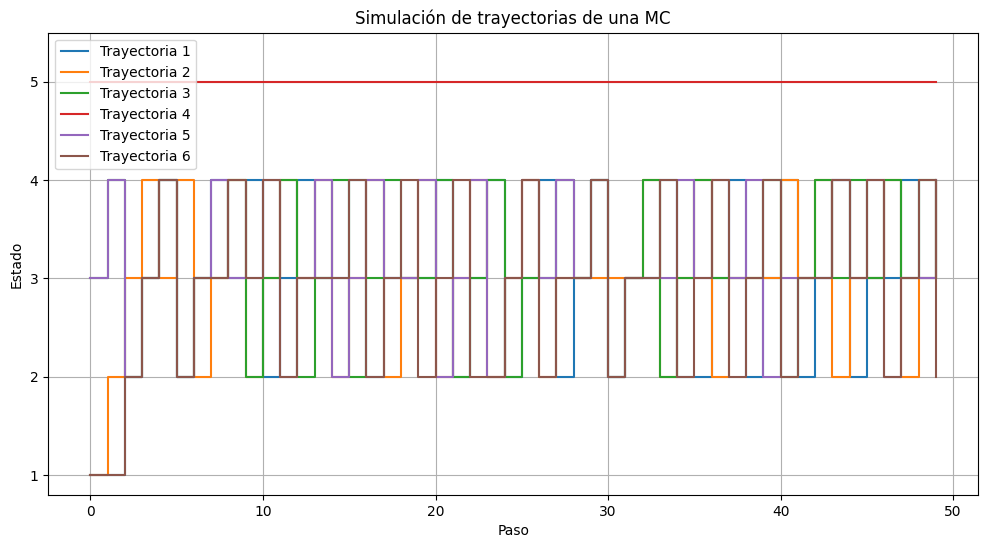

In [59]:
# Visualización
n_samples = 6
n_steps = 50
pi_sup_1 = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])

trayectorias = simular_trayectorias_effic(P, pi_sup_1, n_samples, n_steps)
tray = trayectorias+1

x = np.arange(n_steps)
plt.figure(figsize=(12,6))

for i in range(n_samples):
    plt.step(x, tray[i], where="post", label=f"Trayectoria {i+1}")

plt.yticks([1,2,3,4,5])
plt.ylim(0.8,5.5)
plt.xlabel("Paso")
plt.ylabel("Estado")
plt.title("Simulación de trayectorias de una MC")
plt.legend()
plt.grid(True)

plt.show()

## Distribución marginal de una MC
Vamos a definir una función que nos permita obtener la marginal de una MC en un momento dado.

In [83]:
def obtener_marginal(P, pi_sup_1, n):
  P_n = np.linalg.matrix_power(P, n-1)
  marginal = pi_sup_1 @ P_n
  return marginal

A continuación voy a poner a prueba la función para visualizar empíricamente que la distribución marginal de nuestra MC ocnverge a diferentes distribuciones si empezamos en distribuciones iniciales diferentes. Se van a reproducir las imágenes de las diapositivas 61 y 63 de teoría.

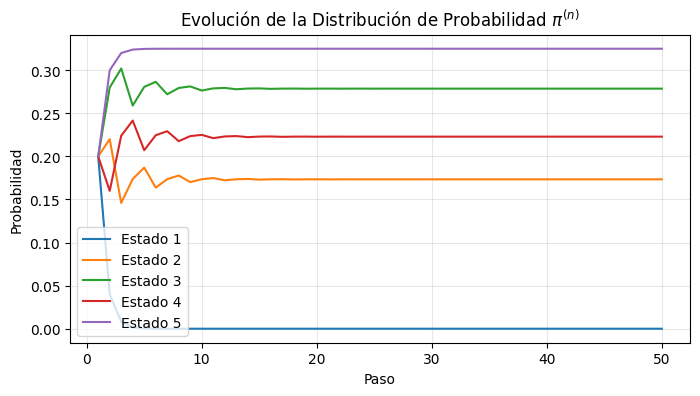

In [61]:
# Visualización de la diapositiva 61
P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
pi_sup_1 = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
n_steps = 50
m = P.shape[0]

marginales = np.zeros((m, n_steps))
for i in range(n_steps):
  marginales[:,i] = obtener_marginal(P, pi_sup_1, i+1)

plt.figure(figsize=(8,4))
for j in range(m):
  plt.plot(np.arange(1, n_steps+1), marginales[j,:], label=f"Estado {j+1}")

plt.xlabel("Paso")
plt.ylabel("Probabilidad")
plt.title(r"Evolución de la Distribución de Probabilidad $\pi^{(n)}$")
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

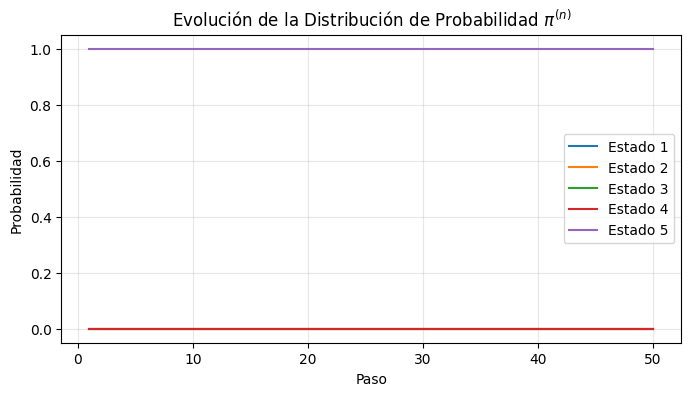

In [62]:
# Visualización de la diapositiva 63
P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
pi_sup_1 = np.array([0, 0, 0, 0, 1])

n_pasos = 50
m = P.shape[0]

marginales = np.zeros((m, n_pasos))
for i in range(n_pasos):
  marginales[:,i] = obtener_marginal(P, pi_sup_1, i+1)

plt.figure(figsize=(8, 4))
for j in range(m):
    plt.plot(np.arange(1, n_steps+1), marginales[j,:], label=f"Estado {j+1}")
plt.xlabel("Paso")
plt.ylabel("Probabilidad")
plt.title(r"Evolución de la Distribución de Probabilidad $\pi^{(n)}$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Diagrama de transición de estados
Vamos a definir una función para dibujar el diagrama de transición de estados de una MC.

In [84]:
import networkx as nx

def dibujar_diagrama_transicion(P, states):

  # Usa DiGraph (Directed Graph)
  G = nx.DiGraph()
  for i in range(len(P)):
      for j in range(len(P)):
          if P[i, j] > 0:
              G.add_edge(states[i], states[j], weight=P[i, j])

  # Define layout
  pos = nx.circular_layout(G)

  # Crea la gráfica
  plt.figure(figsize=(8, 6))

  # Dibuja los nodos y aristas
  # 'connectionstyle' curva las aristas para impedir que se solapen las que son bidireccionales
  nx.draw(G, pos, with_labels=True, node_color='lightblue',
          node_size=800, arrowsize=20,
          connectionstyle='arc3, rad = 0.1')

  # 2. Añade los pesos como etiqueta
  edge_labels = nx.get_edge_attributes(G, 'weight')

  # Opcional: Formatea las etiquetas para que se vea más limpio (ie, 0.5 en vez de of 0.500000)
  formatted_edge_labels = {k: f"{v:g}" for k, v in edge_labels.items()}

  nx.draw_networkx_edge_labels(G, pos, edge_labels=formatted_edge_labels, label_pos=0.2)

  plt.title("Diagrama de transición de estados con pesos")
  plt.show()

Usamos la función para dibujar el diagrama de transición de estados de la diapositiva 27.

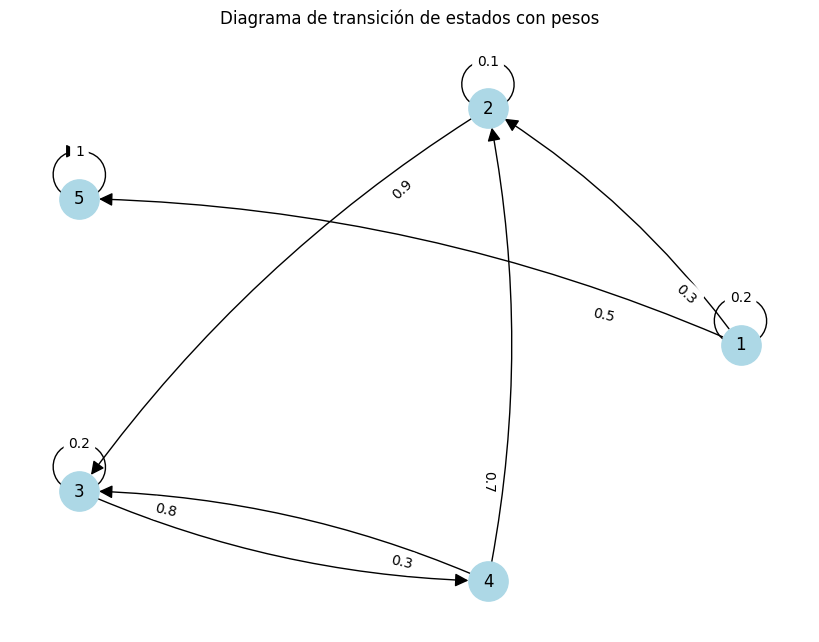

In [64]:
# Visualización diapositiva 27
P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])

states = np.array([1, 2, 3, 4, 5])
dibujar_diagrama_transicion(P, states)

## Teorema de convergencia de MCs
En esta sección vamos a ilustrar tres ideas que hemos estudiado en el contexto del teorema de convergencia de MCs:

1. Una MC es unicadenal y aperiódica $\iff$ la distribución marginal converge siempre a la misma distribución (independientemente de la distribución inicial).
2. Una MC es aperiódica $\iff$ la distribución marginal converge siempre (aunque el límite puede depender de la distribución inicial).
3. Para MCs en las hipótesis del teorema de convergencia de MCs, la distribución empírica de proporciones del estado $i$-ésimo, lo que habíamos llamado $p_i(n_{samples}, n_{steps})$, converge a la componente $i$-ésima de la distribución estacionaria cuando incrementamos $n_{samples}, n_{steps}$.


Vamos a definir una función que nos permita visualizar la evolución de la distribución marginal de una MC.

In [85]:
def visualizar_evolucion_marginal(P, pi_sup_1, n_steps):

  # Paso 1: crear un array con shape (n_steps, m) y rellenarlo con las marginales en cada paso
  m = P.shape[0]

  pi = np.array(pi_sup_1).flatten()
  marginales = np.zeros((n_steps, m))
  marginales[0,:] = pi

  for i in range(1, n_steps):
    pi = pi @ P
    marginales[i,:] = pi

  # Paso 2: Dibujar la trayectoria de cada componente marginal
  plt.figure(figsize=(8,4))
  for j in range(m):
    # Corrected: marginales[:,j] plots the evolution of state j over n_steps
    plt.plot(np.arange(1, n_steps+1), marginales[:,j], label=f"Estado {j+1}")

  plt.xlabel("Paso")
  plt.ylabel("Probabilidad")
  plt.title(r"Evolución de la Distribución de Probabilidad $\pi^{(n)}$")
  plt.legend()
  plt.grid(alpha = 0.3)
  plt.show()

Se considera la siguiente matriz de transición:

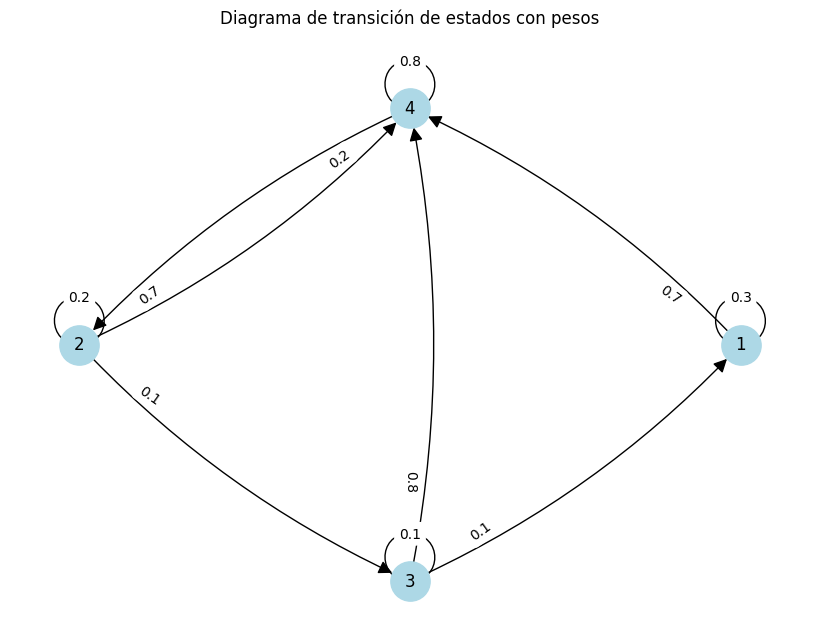

In [66]:
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])
dibujar_diagrama_transicion(P, [1,2,3,4])

Comprueba que una MC con esta matriz de transición es unicadenal (de hecho es irreducible) y aperiódica. Por tanto, está en las condiciones del teorema de convergencia de MCs. Por tanto, la marginal debe converger a una única distribución estacionaria independientemente de la distribución inicial.

En la siguiente celda se obtiene una distribución inicial aleatoria para la MC, y se representan los primeros $50$ pasos de la marginal (también se imprime por pantalla la marginal en el paso 50). Completa la celda y luego ejecútala varias veces para comprobar que siempre se converge al mismo límite.

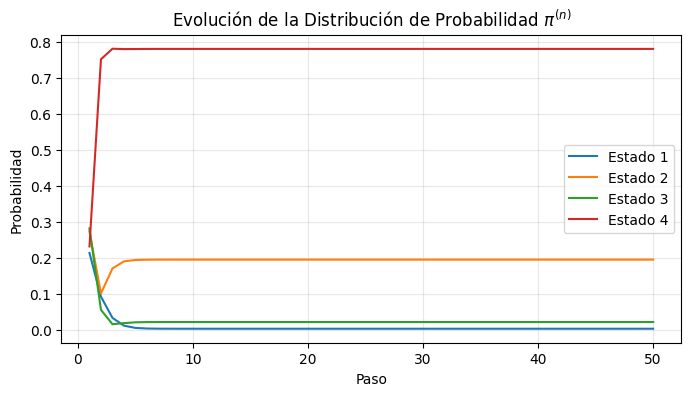

[0.00309598 0.19504644 0.02167183 0.78018576]


In [67]:
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])

# Define m based on the current P matrix to avoid size mismatch
m = P.shape[0]

# Generate a random pi_sup_1 of the correct size and normalize it
pi_sup_1 = np.random.rand(m)
pi_sup_1 = pi_sup_1 / np.sum(pi_sup_1) # Corrected normalization to np.sum

visualizar_evolucion_marginal(P, pi_sup_1, 50)
print( obtener_marginal(P, pi_sup_1, 50) )

Cuando hicimos un esbozo de demostración del teorema de convergencia de MCs vimos que la sucesión de matrices $\{P^n\}_n$ convergía a una matriz en la que todas las filas eran iguales (y coincidían con la única distribución estacionaria).

Vamos a visualizar varios términos de esta sucesión para comprobar empíricamente que esto sucede. Primero vamos a ver cómo podemos representar visualmente una matriz. Una manera habitual es mediante un "heatmap" (mapa de calor). A continuación se realiza dicho gráfico para la MC anterior:

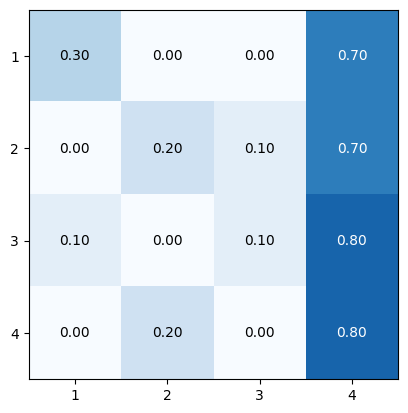

In [68]:
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])

# Dibujar el heatmap
plt.imshow(P, cmap='Blues', vmin=0, vmax=1)

# Añadir texto con los valores explícitos
m = P.shape[0]
for i in range(m):       # rows
        for j in range(m):   # columns
            value = P[i, j]
            # Dynamically change text color based on cell brightness for readability
            text_color = "white" if value > 0.5 else "black"
            # Add text (note: text coordinates are (column, row) -> (j, i))
            plt.text(j, i, f"{value:.2f}",
                    ha="center", va="center",
                    color=text_color, fontsize=10)

plt.xticks(np.arange(P.shape[0]), labels=1+np.arange(P.shape[0]))
plt.yticks(np.arange(P.shape[0]), labels=1+np.arange(P.shape[0]))

plt.show()

Veamos la evolución de $\{P^n\}_n$ en tres instantes: $n=1,2,10$. Comprueba que, efectivamente, esta sucesión parece estabilizarse en una matriz en las que todas las filas son la misma. Y que además coincide con la distribución estacionaria que obtuvimos empíricamente dos celdas más arriba, cuando vimos dónde parecía estabilizarse la marginal de la MC en el paso $50$. (Recuerda que parecía estabilizarse en [0.00309598 0.19504644 0.02167183 0.78018576]).

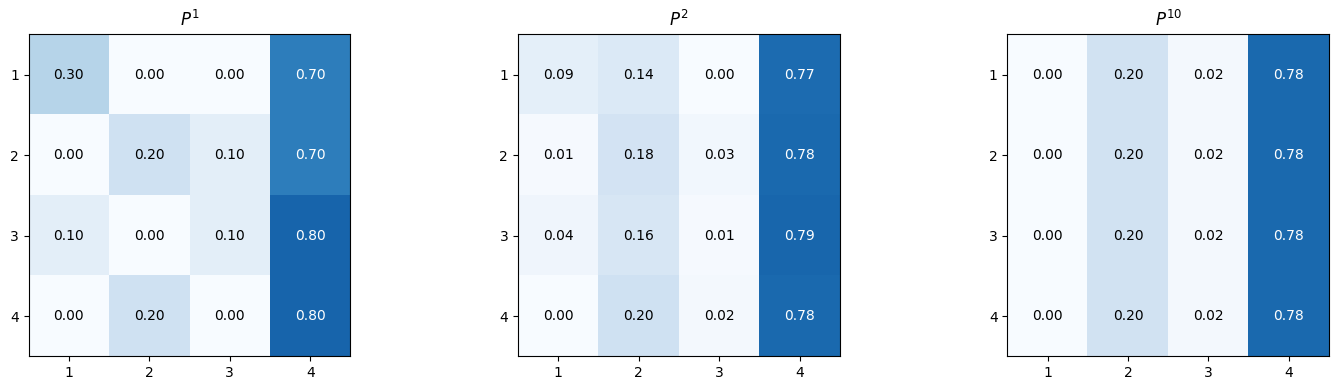

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
steps_to_show = [1, 2, 10]

for ax, n in zip(axes, steps_to_show):

    Pn = np.linalg.matrix_power(P, n)

    im = ax.imshow(Pn, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f"$P^{{{n}}}$")
    ax.set_xticks(np.arange(P.shape[0]), labels=1+np.arange(P.shape[0]))
    ax.set_yticks(np.arange(P.shape[0]), labels=1+np.arange(P.shape[0]))
    # Loop over data dimensions and create text annotations
    for i in range(Pn.shape[0]):       # rows
        for j in range(Pn.shape[1]):   # columns
            value = Pn[i, j]

            # Dynamically change text color based on cell brightness for readability
            text_color = "white" if value > 0.5 else "black"

            # Add text (note: text coordinates are (column, row) -> (j, i))
            ax.text(j, i, f"{value:.2f}",
                    ha="center", va="center",
                    color=text_color, fontsize=10)

plt.tight_layout()
plt.show()

Vemos ahora una MC que sea periódica. Para ello se comprueba que la siguiente cadena lo es:

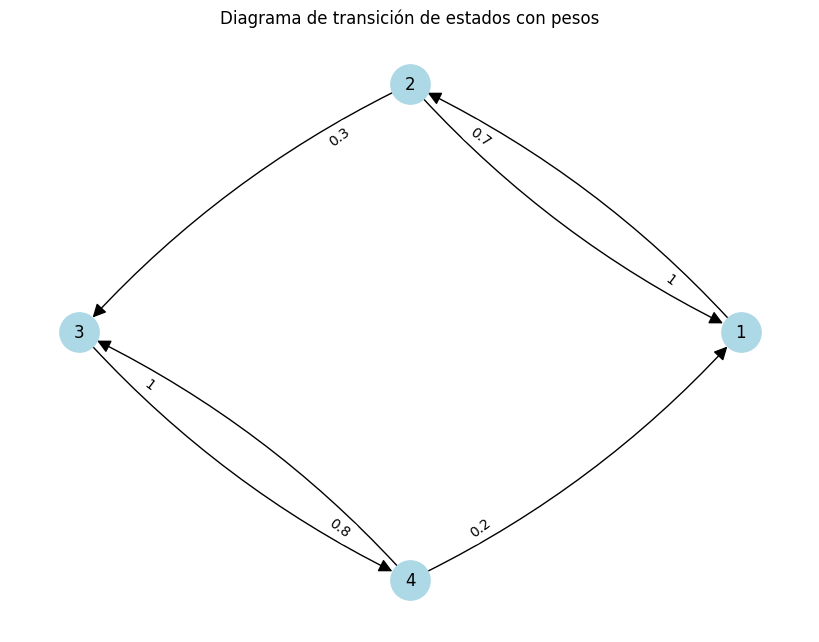

In [70]:
P = np.array([[0.0,1.0,0.0,0.0],
              [0.7,0.0,0.3,0.0],
              [0.0,0.0,0.0,1.0],
              [0.2,0.0,0.8,0.0]])
dibujar_diagrama_transicion(P, np.arange(1,P.shape[0]+1))

En las siguientes celdas se usa la función 'visualizar_evolucion_marginal'.

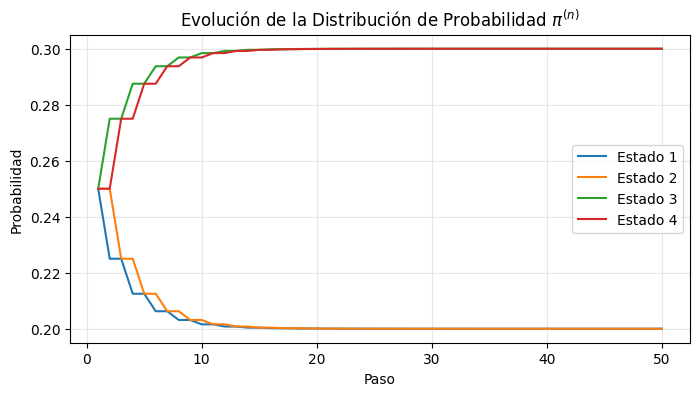

[0.2 0.2 0.3 0.3]


In [71]:
pi_sup_1 = np.array([0.25, 0.25, 0.25, 0.25])
visualizar_evolucion_marginal(P, pi_sup_1, 50)
print(obtener_marginal(P, pi_sup_1, 50) )

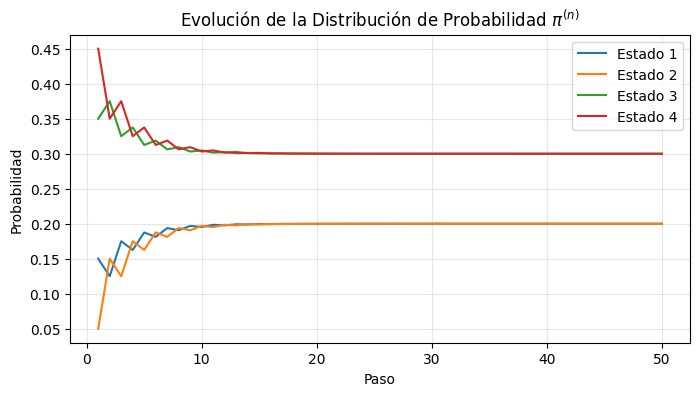

[0.2 0.2 0.3 0.3]


In [72]:
pi_sup_1 = np.array([0.15, 0.05, 0.35, 0.45])
visualizar_evolucion_marginal(P, pi_sup_1, 50)
print(obtener_marginal(P, pi_sup_1, 50) )

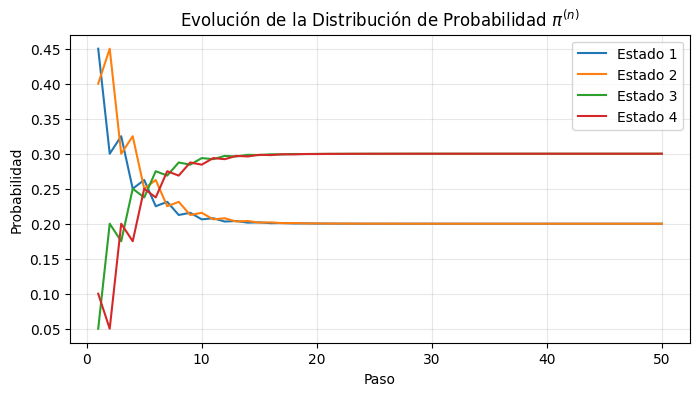

[0.20000001 0.20000001 0.29999999 0.29999999]


In [73]:
pi_sup_1 = np.array([0.45, 0.40, 0.05, 0.10])
visualizar_evolucion_marginal(P, pi_sup_1, 50)
print(obtener_marginal(P, pi_sup_1, 50) )

En los tres casos parecen producirse convergencia de la marginal a la distribución [0.2 0.2 0.3 0.3]. Efectivamente, se puede demostrar que la MC converge para esas tres condiciones iniciales.

Vemos ahora que esto no contradice el resultado de teoría. Se propone para ello una distribución inicial para la que no hay convergencia:

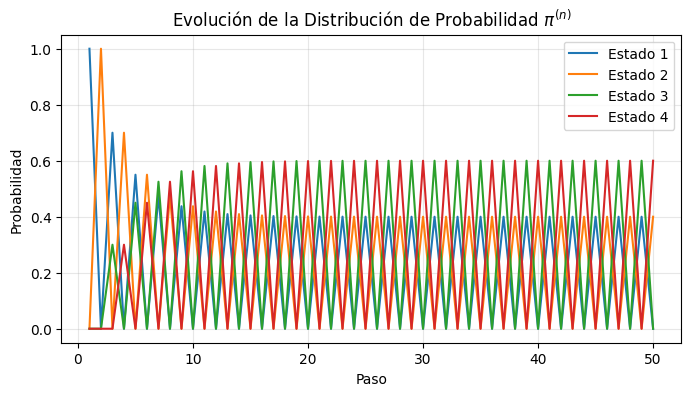

[0.         0.40000004 0.         0.59999996]


In [74]:
pi_sup_1 = np.array([1, 0, 0, 0])
visualizar_evolucion_marginal(P, pi_sup_1, 50)
print(obtener_marginal(P, pi_sup_1, 50) )

En la siguiente celda, vamos a definir una función que calcula las proporciones $p_i(n_{samples}, n_{steps})$ para una trayectoria aleatoria de una MC dada.

De hecho, dada la MC y dados los valores de $n_{samples}$ y $n_{steps}$, la siguiente función devuelve todas las proporciones $p_i(n_{samples}, n)$ con $i=1,\dots,m$ y $n=1,\dots,n_{steps}$.

In [86]:
def proporciones_empiricas_hasta_cierto_paso(n_samples, n_steps, P, pi_sup_1):

  # Paso 1: simular n_samples trayectorias durante n_steps pasos.
  trayectorias = simular_trayectorias_effic(P, pi_sup_1, n_samples, n_steps)

  # Paso 2: comparar cada item del array anterior con cada uno de los estados.
  # El objetivo es obtener un array "is_equal_bool" de shape (m, n_samples, n_steps) que en cada posición (i,j,k) contenga True/False según si el ítem (j,k) del array es igual a "i" (True) o no lo es.
  m = P.shape[0]
  estados = np.arange(m).reshape((m,1,1))
  is_equal_bool = (estados == trayectorias[np.newaxis,:,:])

  # Paso 3: las proporciones a devolver no son más que hacer la media en la dimensión de "n_samples" en el array de antes (suponiendo que True cuenta como +1 y False como +0).
  props = np.mean(is_equal_bool, axis=1)

  return props

Utiliza la función anterior para visualizar la evolución de $p_i(k,k)$ para cada uno de los $i=1,\dots,m$ cuando $k$ crece. Vamos a hacer la visualización para la MC aperiódica y unicadenal que usamos al principio de esta sección. Para ello, rellena la siguiente celda:

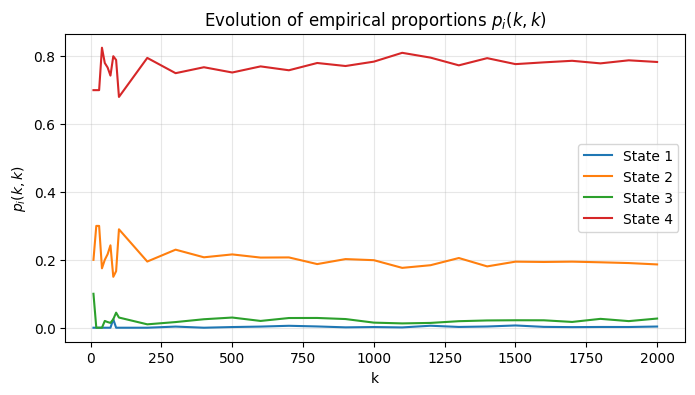

[0.0035 0.1865 0.027  0.783 ]
[0.00309598 0.19504644 0.02167183 0.78018576]


In [76]:
# Definimos la MC
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])
pi_sup_1 = np.array([0.25, 0.25, 0.25, 0.25])
m = P.shape[0]

# Definimos el "grid" de valores k que vamos a recorrer: 10, 20, 30, ... 100, 200, 300, ..., 2000
grid = np.concatenate( (np.arange(10, 101, 10),
                        np.arange(200, 2001, 100)) )

# Obtenemos p_i(k,k) para i=1,...,m y para k en el grid anterior.
# Guardamos los resultados en un array "props_plot" de shape (m, len(grid)). (Nótese que len(grid) no es más que la longitud del grid).
props_plot = np.zeros((m, len(grid)))   # (m, len(grid))
for j in range(len(grid)):
  props_plot[:,j] = proporciones_empiricas_hasta_cierto_paso(grid[j], grid[j], P, pi_sup_1)[:,-1]

# A continuación se hace el gráfico.
plt.figure(figsize=(8, 4))
for i in range(m):
  plt.plot(grid, props_plot[i,:], label=f"State {i+1}")
plt.xlabel("k")
plt.ylabel(r"$p_i(k,k)$")
plt.title(r"Evolution of empirical proportions $p_i(k,k)$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Mostramos por pantalla dos cosas:
# Primero, las proporciones para el último valor de k, es decir, p_i(2000,2000).
# Segundo, la distribución estacionaria de la MC.
# Según vimos en clase, lo primero debería parecerse a lo segundo para k grande. Y efectivamente vemos que es así.
# No obstante, dependiendo de la ejecución concreta, se parecerá más o menos (una cuestión interesante sería estudiar la velocidad de convergencia, que no parece ser muy elevada porque, para k=2000, aún no parece estabilizarse del todo)
print(props_plot[:,-1])
print(obtener_marginal(P, pi_sup_1, 50) )

## Teorema ergódico
Vamos a verificar empíricamente el teorema ergódico para algunas MCs.

El teorema ergódico se enunciaba para una función $f:S\to\mathbb{R}$ arbitraria. Aquí vamos a considerar la función indicadora $f_i$ que se comentó en la diapositiva 107. Por tanto, estaremos calculando lo que denotábamos por $q_i(n)$ en la diapositiva 106. Recuerda que $q_i(n)$ no es más que la frecuencia (o proporción) de visita al estado $i$-ésimo para una trayectoria aleatoria de la MC, es decir:


$$q_i(n) = \frac{\textrm{Cantidad de veces que se visita $i$ en los $n$ primeros pasos}}{n}$$

Como sabemos, se debe cumplir $q_i(n)\geq 0$ y $\sum_i q_i(n) = 1$.  

Vamos a empezar por definir una función que, dada una MC (```P``` y ```pi_sup_1```) y una cantidad de pasos ```n_steps```, calcule las cantidades $q_i(n)$ para cada $i=1,\dots,m$ y cada $n=1,\dots,n_{steps}$. Estos valores los devolverá en un array con shape (m, n_steps).

In [100]:
def frecuencia_empirica_hasta_cierto_paso(n_steps, P, pi_sup_1):

  # Paso 1: simular una trayectoria para la MC, hasta el paso n_steps
  m = P.shape[0]
  trayectoria = simular_trayectorias_effic(P, pi_sup_1, 1, n_steps) # Shape (1, n_steps)

  # Paso 2: compara cada valor obtenido con cada uno de los m posibles estados.
  # El objetivo es obtener un array "is_equal_bool" de shape (m, n_steps) que en la posición (i,j) contenga True/False: True si en el paso j la trayectoria ha visitado justo el estado i, y False en otro caso.
  estados = np.arange(m).reshape((m, 1))
  is_equal_bool = (estados == trayectoria)

  # Paso 3: A partir del array "is_equal_bool", obtener "recuentos_hasta_cierto_paso".
  recuentos_hasta_cierto_paso = np.cumsum(is_equal_bool, axis=1) # Shape (m, n_steps)

  # Paso 4: A partir del array "recuentos_hasta_cierto_paso", obtener el array "frecuencias_hasta_cierto_paso".
  pasos = np.arange(1, n_steps + 1).reshape(1, n_steps) # Shape (1, n_steps)

  frecuencias_hasta_cierto_paso = (recuentos_hasta_cierto_paso / pasos)

  return frecuencias_hasta_cierto_paso

Vamos a usar esta función para visualizar el teorema ergódico en dos MCs que son unicadenales, y por tanto están en las hipótesis del teorema ergódico. Primero miraremos una aperiódica (y que por tanto también está en las condiciones del teorema de convergencia de MCs) y luego miraremos una periódica (y que por tanto NO está en las condiciones del teorema de convergencia de MCs).

Como unicadenal aperiódica tomamos la que hemos usado al principio de la sección 4 anterior:

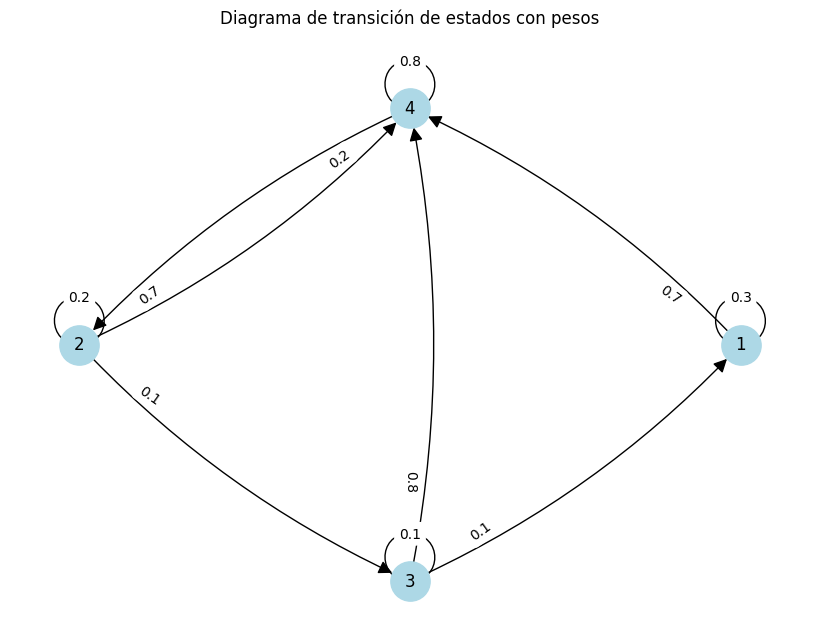

In [78]:
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])
dibujar_diagrama_transicion(P, [1,2,3,4])

Recordamos de la sección 4 que la distribución estacionaria de esta MC parecía estar entorno a
$$[0.003, \; 0.195, \; 0.022, \; 0.780]$$
puesto que la marginal se estabilizaba en esos valores. Veamos que, tal y como garantiza el teorema ergódico, las cantidades $q_i(n)$ convergen a la distribución estacionaria, es decir, $q_i(n) \to (\pi)_i$ cuando $n\to\infty$.

En la siguiente celda se representa la evolución de cada una de las $q_i(n)$ cuando $n$ crece (desde $1$ hasta $10000$). Al final del todo también se imprimen por pantalla los valores de $q_i(10000)$, para poder compararlos con la distribución estacionaria.

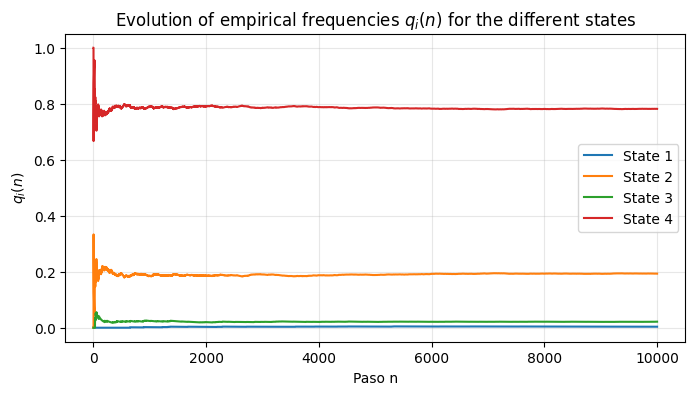

[0.0036 0.1931 0.0216 0.7817]


In [101]:
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])
pi_sup_1 = np.array([0.25, 0.25, 0.25, 0.25])

n_steps = 10000
m = P.shape[0]

frecs = frecuencia_empirica_hasta_cierto_paso(n_steps,P,pi_sup_1)

plt.figure(figsize=(8, 4))
for i in range(m):
  plt.plot(np.arange(1, n_steps+1), frecs[i,:] , label=f"State {i+1}")  ## COMPLETAR
plt.xlabel("Paso n")
plt.ylabel(r"$q_i(n)$")
plt.title(r"Evolution of empirical frequencies $q_i(n)$ for the different states")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(frecs[:,-1])

Por último, vamos a considerar la MC periódica que vimos en la sección 4:

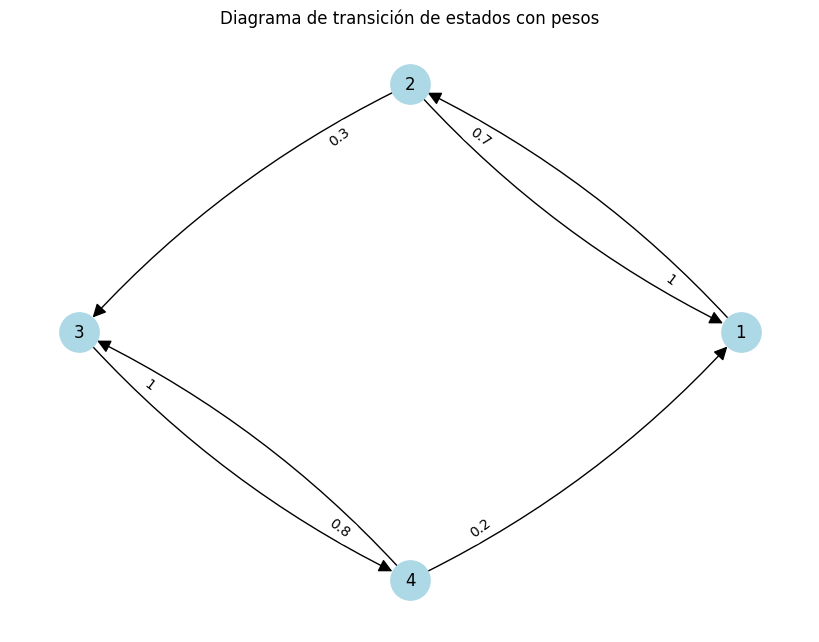

In [102]:
P = np.array([[0.0,1.0,0.0,0.0],
              [0.7,0.0,0.3,0.0],
              [0.0,0.0,0.0,1.0],
              [0.2,0.0,0.8,0.0]])
dibujar_diagrama_transicion(P, np.arange(1,P.shape[0]+1))

Vamos a seleccionar una distribución inicial ```pi_sup_1``` para la que sabemos que la distribución marginal no converge, como se vio en la sección 4. Y vamos a ver que, aunque la distribución marginal no converge, sí que se cumple el teorema ergódico, y las frecuencias a lo largo de una trayectoria sí que convergen a la distribución estacionaria. En efecto, recuerda que el teorema ergódico no requiere "aperiodicidad" (a diferencia del teorema de convergencia de MCs).

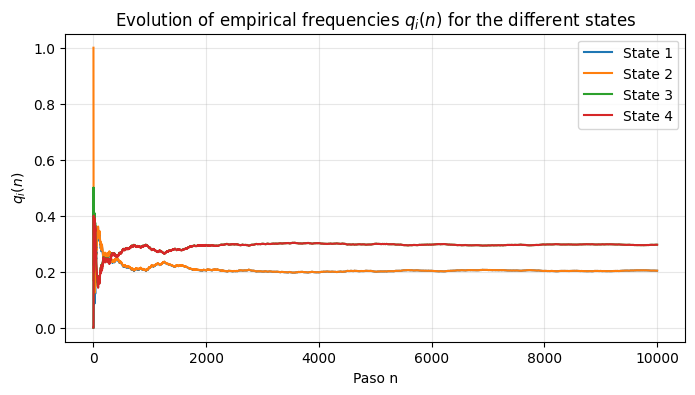

[0.2036 0.2037 0.2964 0.2963]


In [104]:
P = np.array([[0.0,1.0,0.0,0.0],
              [0.7,0.0,0.3,0.0],
              [0.0,0.0,0.0,1.0],
              [0.2,0.0,0.8,0.0]])
pi_sup_1 = np.array([0.2, 0.3, 0.2, 0.3])

n_steps = 10000
m = P.shape[0]

frecs = frecuencia_empirica_hasta_cierto_paso(n_steps,P,pi_sup_1)  # (m, n_steps)

plt.figure(figsize=(8, 4))
for i in range(m):
  plt.plot(np.arange(1, n_steps+1), frecs[i] , label=f"State {i+1}")  ## COMPLETAR
plt.xlabel("Paso n")
plt.ylabel(r"$q_i(n)$")
plt.title(r"Evolution of empirical frequencies $q_i(n)$ for the different states")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(frecs[:,-1])

Esto converge al valor esperado.